<a href="https://colab.research.google.com/github/ravindravala/AI/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torchvision
from torch.utils.data import DataLoader,Dataset
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

In [3]:
transform = transforms.ToTensor()

In [14]:
train_dataset = torchvision.datasets.FashionMNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data',train=False,download=True,transform=transform)

In [15]:
import matplotlib.pyplot as plt

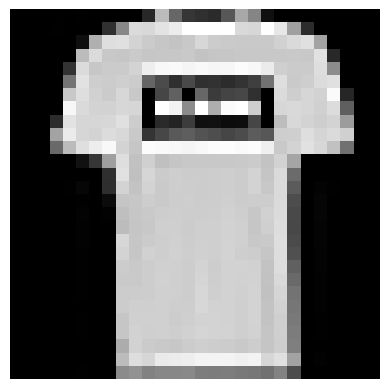

In [18]:
image, label = train_dataset[1]

plt.imshow(image.squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [19]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [22]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [24]:
image, label = train_dataset[0]

print(image.shape)

torch.Size([1, 28, 28])


In [30]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.linear = nn.Linear(1352, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        return x

In [31]:
model = SimpleCNN()

In [32]:
optimizer = optim.Adam(model.parameters(),lr=0.001)
loss_fun = nn.CrossEntropyLoss()


In [34]:
epochs=5

for epoch in range(epochs):
    for images, labels in train_loader:
      pred = model(images)
      loss = loss_fun(pred,labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")



Epoch 1/5, Loss: 0.3219985067844391
Epoch 2/5, Loss: 0.48838236927986145
Epoch 3/5, Loss: 0.6208335161209106
Epoch 4/5, Loss: 0.5579245090484619
Epoch 5/5, Loss: 0.5807576775550842


In [37]:
model.eval()

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)


        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 87.32%
